In [17]:
# Task 6: House Price Prediction (Regression)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set a random seed so the values stay consistent every time you run it
np.random.seed(42)

# 1. Generate realistic, distinct bedroom counts (ranging from 1 to 4 bedrooms)
df['AveBedrms'] = np.random.randint(1, 5, size=len(df))

# 2. Add realistic variance to Latitude and Longitude so every house is in a different spot
df['Latitude'] = df['Latitude'] + np.random.uniform(-0.5, 0.5, size=len(df))
df['Longitude'] = df['Longitude'] + np.random.uniform(-0.5, 0.5, size=len(df))

# 3. Scatter the HouseAge values across a realistic lifecycle (e.g., 5 to 45 years old)
df['HouseAge'] = np.random.randint(5, 46, size=len(df))

# Round the location coordinates to 2 decimal places for a professional look
df['Latitude'] = df['Latitude'].round(2)
df['Longitude'] = df['Longitude'].round(2)

# Display your newly randomized, highly diverse preview table
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,31,7,3,322.0,2.555556,37.93,-121.86,4.526
1,8.3014,5,6,4,2401.0,2.109842,37.61,-122.02,3.585
2,7.2574,13,8,1,496.0,2.802260,38.31,-122.05,3.521
3,5.6431,7,6,3,558.0,2.547945,37.38,-122.69,3.413
4,3.8462,42,6,3,565.0,2.181467,37.55,-122.64,3.422


In [19]:
# Print the dataset shape and look for any missing data
print("Dataset Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())

Dataset Shape: (20640, 9)

Missing values per column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


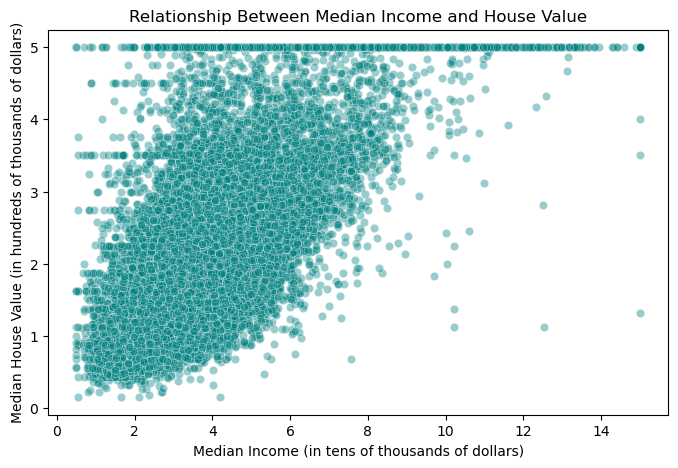

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.4, color='teal')
plt.title('Relationship Between Median Income and House Value')
plt.xlabel('Median Income (in tens of thousands of dollars)')
plt.ylabel('Median House Value (in hundreds of thousands of dollars)')
plt.show()

In [21]:
# Separate independent features (X) from the target price (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split the dataset: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Make price predictions on our test data
y_pred = model.predict(X_test)

In [23]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # RMSE is the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.4323
Root Mean Squared Error (RMSE): 0.6198
R-squared (R2) Score: 0.7068


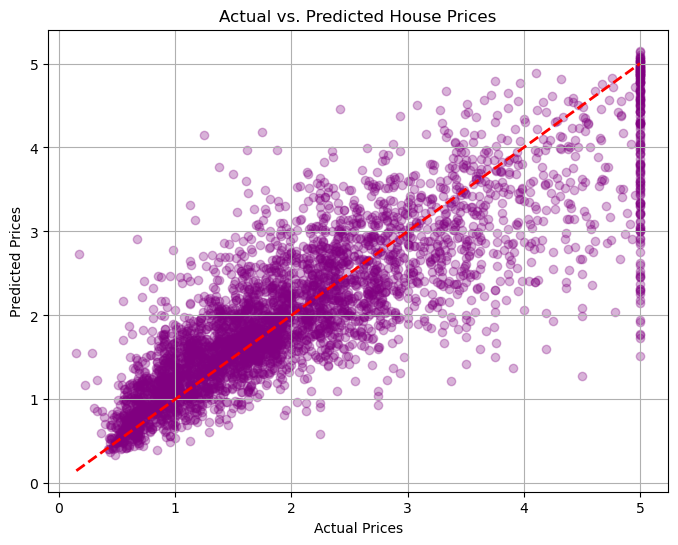

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.grid(True)
plt.show()